# I. Introductions


This chapter explores how machine learning (ML) can be applied to networks, particularly **friendship networks**, by leveraging both **network structure** and **individual metadata**. While traditional network analysis tools are useful for understanding structure and spread, ML provides a way to enrich this analysis by incorporating additional information about individuals and their connections.

Key topics covered include:

* **Network construction** using shared activities and traits.
* **Clustering** based on a combination of network metrics and metadata.
* **Prediction of outcomes** (e.g., individual attributes or connection strength) using ML models.
* Integration of **network features** with **ML models** to provide deeper insights.
* Applications of **standard ML** and **semi-supervised deep learning (SDL)** techniques on relational data.

The chapter sets the foundation for applying ML to networks, preparing readers for more advanced topics in later chapters.

---

In this notebook, we explore a **friendship network** of 25 high school students, based on shared activities such as sports teams, study groups, elective classes, and neighborhood ties. The data, originally derived from a student diary (Farrelly, student #7), captures both **strong social ties** (e.g., close friendships formed through frequent interactions) and **weak ties** (e.g., casual connections through shared classes).

Strong ties often influence personal development and behavior, while weak ties play a key role in spreading new ideas and connecting different social groups. Understanding both types of relationships helps us model how information, behaviors, or even illnesses might spread through a student network.

We'll begin by building a **weighted social graph** where connections are based on shared activities. Using **unsupervised learning**, we'll cluster students into likely friendship groups. Later, we’ll apply **graph-based supervised learning** methods such as **Graph Neural Networks (GNNs)** to assess social network risks, including potential epidemic spread patterns.

This notebook combines **network analysis**, **metadata exploration**, and **machine learning** to better understand the dynamics of adolescent social structures.



# II. Classical Machine learning techniques

## 1. Import Functions

In [1]:
#import packages needed
import pandas as pd
from sklearn.cluster import KMeans
import igraph as ig
from igraph import Graph
import numpy as np
import os
import igraph as ig
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

import random
import networkx as nx
import json

## 2. Pure K-means Clustering 

In [2]:
#import file
File ="/home/sako/Data science lessons/Graph Theory/Book Course (Python with Network science)/git_directory/graph_network_data_science/data/Friendship_Factors.csv"
mydata =pd.read_csv(File,encoding='latin1')

In [3]:
#k-means model
X=mydata[mydata.columns.drop('Individual ID')]
km=KMeans(n_clusters=3,init='random',n_init=5,random_state=5)
km_model=km.fit_predict(X)

#explore k-means model
km_model

array([2, 2, 2, 2, 2, 2, 2, 0, 0, 2, 1, 0, 0, 1, 1, 0, 1, 1, 2, 1, 1, 1,
       0, 0, 0], dtype=int32)

In [4]:
#add to dataset as first solution
km_1=np.array(km_model)+1
mydata['km_1']=km_1

#### Cluster 1

In [5]:
mydata.sort_values('Individual ID').query("km_1==1")

,Individual ID,Current Teammates,Workout Together,Weekend Sports,Attended Game,Homework Together,Class 1,Class 2,Class 3,Class 4,km_1
7,8,1,0,0,1,0,0,1,0,1,1
8,9,1,0,0,1,0,0,1,0,0,1
11,12,1,0,0,0,0,0,1,0,0,1
12,13,0,0,0,0,0,1,1,0,0,1
15,16,1,0,0,0,0,0,1,0,0,1
22,23,1,0,0,0,0,0,1,0,0,1
23,24,0,0,0,0,0,0,1,0,0,1
24,25,0,0,0,0,0,0,1,0,0,1


Cluster characteristics:
- Current teamates
- They don't share workouts or weekend sports
- Don't do homework together
- take some similar classes
- They just take Class 2 togther

Thet seem to be of low risk for sort of a pandemic due to their lack of involvement

#### Cluster 2

In [6]:
mydata.sort_values('Individual ID').query("km_1==2")

,Individual ID,Current Teammates,Workout Together,Weekend Sports,Attended Game,Homework Together,Class 1,Class 2,Class 3,Class 4,km_1
10,11,0,0,0,0,0,1,0,0,0,2
13,14,1,0,0,1,0,1,0,0,0,2
14,15,1,0,0,0,0,1,0,0,1,2
16,17,1,0,0,0,0,0,0,1,0,2
17,18,0,0,0,0,0,1,0,0,0,2
19,20,0,0,0,0,0,0,0,1,0,2
20,21,0,0,0,0,1,0,0,1,1,2
21,22,1,0,0,0,0,0,0,0,0,2


Cluster characteristics:
- Seems like a mix of low activity combinations

Thet seem to be of low risk for sort of a pandemic due to their lack of involvement

#### Cluster 3

In [7]:
mydata.sort_values('Individual ID').query("km_1==3")

,Individual ID,Current Teammates,Workout Together,Weekend Sports,Attended Game,Homework Together,Class 1,Class 2,Class 3,Class 4,km_1
0,1,1,1,0,1,1,1,0,0,1,3
1,2,1,1,1,1,1,1,1,1,0,3
2,3,1,1,1,1,1,1,0,1,0,3
3,4,1,1,1,1,1,0,1,0,1,3
4,5,1,1,0,1,1,0,1,0,1,3
5,6,0,1,0,1,1,0,0,1,0,3
6,7,0,1,1,1,1,0,0,1,1,3
9,10,1,0,0,1,1,0,0,1,1,3
18,19,1,0,0,1,1,1,1,0,0,3


Cluster characteristics:
- Current teamates
- Workout together
- to sports 
- take some similar classes
- They do homeworks together 

Thet seem to be of high risk for sort of a pandemic due to their lack of involvement

## 3. Enhencing Clustering with network statistics

### A. Using the pearson correlation we estimate the relationships between students

Text(0, 0.5, 'Frequency')

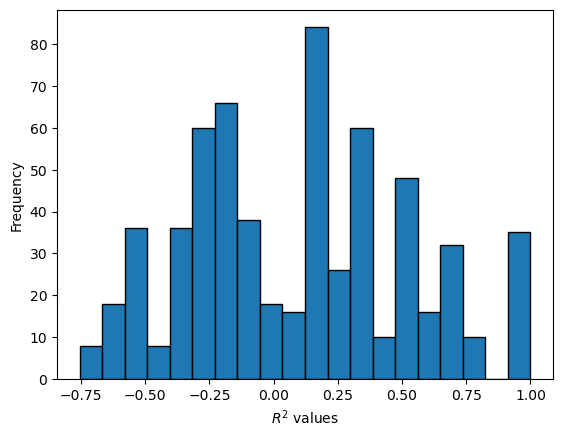

In [8]:
#create network via Pearson correlation
plt.hist(np.corrcoef(X).flatten(),edgecolor='black',bins=20)
plt.xlabel("$R^2$ values")
plt.ylabel("Frequency")


**Visual the relationship for $R^2$ ~ 0.5**

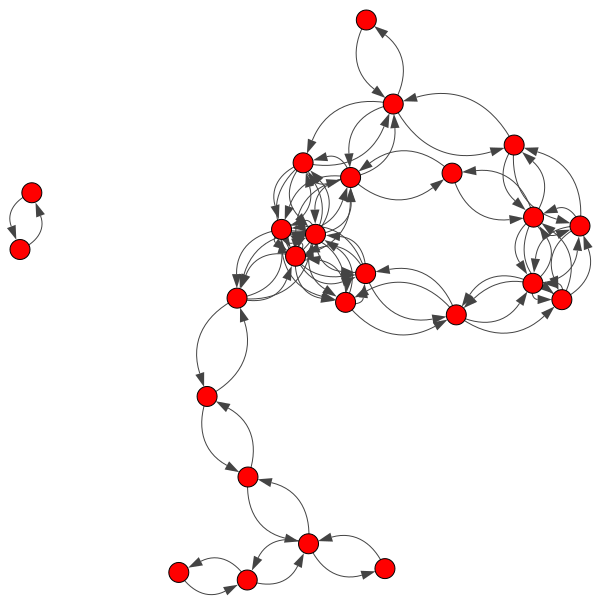

In [9]:
#create network via Pearson correlation
cor=np.corrcoef(X)
cor[cor>=0.5]=1
cor[cor<0.5]=0
X2=np.asmatrix(cor)

#create graph with self-loops removed
friends=Graph.Adjacency(X2)
edge_list=friends.get_edgelist()
self_loop=[]
for i in range(0,25):
    self=(i,i)
    self_loop.append(self)
    
to_remove=[]
for i in edge_list:
    for j in self_loop:
        if i==j:
            to_remove.append(i)

friends.delete_edges(to_remove)

layout = friends.layout("fr")
ig.plot(friends,layout=layout)

### B. Using additional network metrics to do K-means

In [16]:
#create scaled metrics and attach to X
d=np.array(Graph.degree(friends))/10
p=np.array(Graph.pagerank(friends))*20
X.loc[:,'degree']=d
X.loc[:,'pagerank']=p

#create new k-means model with graph metrics added
km2=KMeans(n_clusters=3,init='random',n_init=5,random_state=5)
km_model2=km2.fit_predict(X)

#explore new k-means model
km_model2



array([1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 2, 0, 2, 0, 0, 0, 0, 2, 1, 0, 0, 0,
       0, 2, 2], dtype=int32)

In [17]:
#add to dataset as first solution
km_2=np.array(km_model2)+1
mydata.loc[:,'km_2'] = km_2

### C. Implement Spectral clustering using Sklearn

In [32]:
#import packages needed
from sklearn.cluster import SpectralClustering
from sklearn import metrics #perform spectral clustering and attach to dataset
sc = SpectralClustering(3, affinity='precomputed',n_init=5)
sp_clust=sc.fit(cor)
mydata['sp']=sp_clust.labels_

/home/sako/anaconda3/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:274: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


## 4. Visualize clustering results on top of network 

In [12]:
mydata.sort_values("km_1").groupby("km_1").nunique()[['km_2','sp']]

,km_2,sp
km_1,,
1,2,1
2,2,2
3,1,3


**Note that the cluster migration might different from that othe book**. The data is so small and the algorithm doesn't always convert in the same way. The book has not supplied with a radom seed. I have used it hence if you rerun the code you will get the same result. 

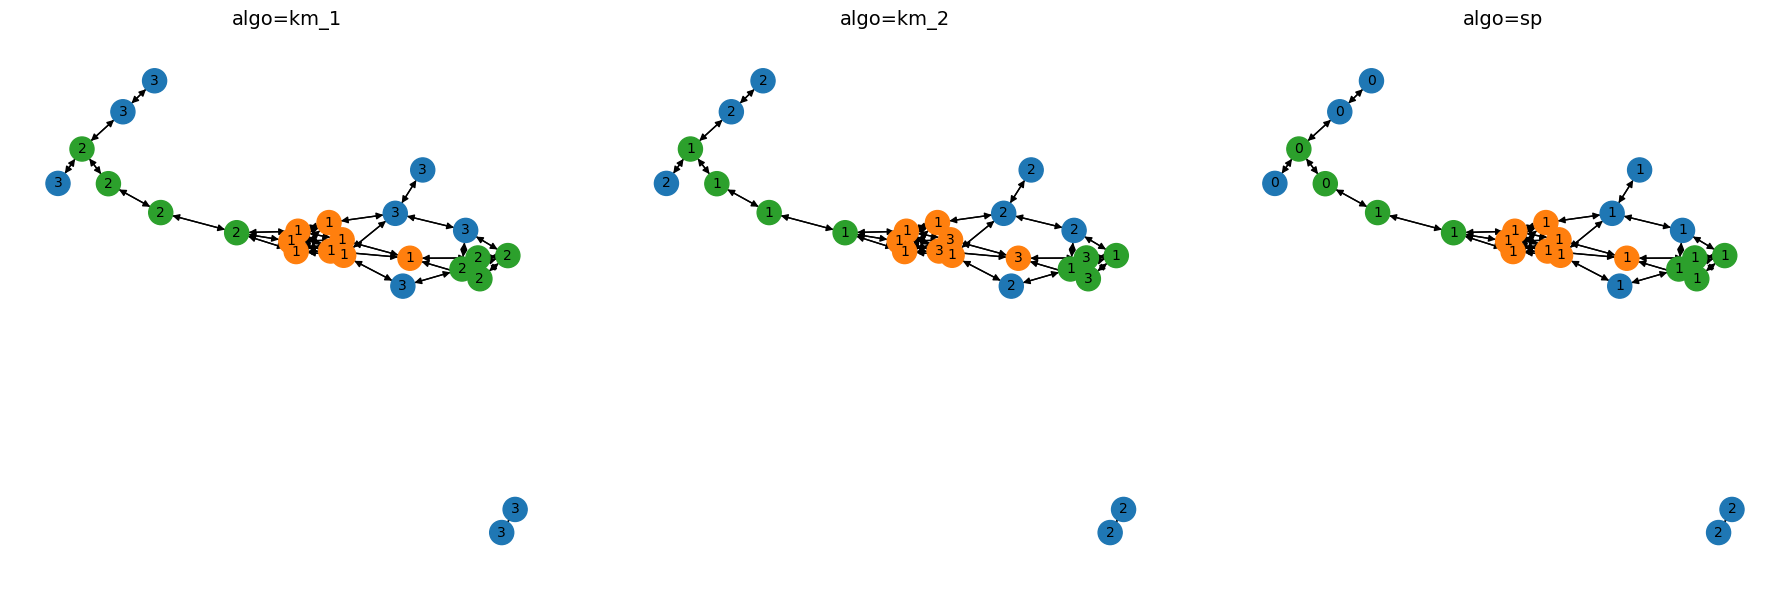

In [13]:
# Convert igraph to networkx (undirected) and save layout
G_nx = friends.to_networkx()
pos = nx.spring_layout(G_nx,seed=42)
serializable_pos = {str(k): v.tolist() for k, v in pos.items()}
with open("./data/layout.json", "w") as f:
    json.dump(serializable_pos, f)

# Load layout
with open("./data/layout.json", "r") as f:
    pos = {int(k): v for k, v in json.load(f).items()}



# Generate distinct colors for each cluster
clusters = mydata['km_1'].unique()
colors = list(mcolors.TABLEAU_COLORS.values())[0:clusters.shape[0]]  # or use mcolors.CSS4_COLORS
colors_map = {val:colors[idx] for idx,val in enumerate(clusters)  }
vertex_colors = mydata['km_1'].replace(colors_map).tolist()

# Create 4x3 subplots (12 total)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes = axes.flatten()

# Convert igraph to networkx (undirected)
G_nx = friends.to_networkx()


# Plot
for idx,val in enumerate(['km_1','km_2','sp']):
    labels = {idx:i for idx,i in enumerate(mydata[val])}
    nx.draw(G_nx,
            ax=axes[idx], 
            pos = pos, 
            with_labels=True,
            labels=labels,
            node_color=vertex_colors,
        node_size=300, font_size=10)
    
    axes[idx].set_title(f"algo={val}", fontsize=14)

# Hide the remaining unused axes
for j in range(3, len(axes)):
    axes[j].set_visible(False)

# Layout adjustments
plt.tight_layout()
plt.subplots_adjust(wspace=0.1, hspace=0.1)
plt.show()

#### Conclusions

* **Spectral clustering** relies only on **network connectivity** (derived from correlations).
* **K-means** considers **individual-level features** like activities and schedules.
* A **hybrid approach** (e.g., k-means with network metrics) may be more appropriate for such data.

#### Key Points:

* Spectral clustering is useful for **pure network-based problems** or when **node attributes are missing**.
* It also supports **semi-supervised learning (SSL)** when partial labels are available.
* For **large networks**, k-means (with scalable features) is often more **efficient** and **interpretable**.



# III. Deep Learning

### 1. Introduction to Graph Neural Networks (GNNs)

Graph Neural Networks (GNNs) are deep learning models designed to work with graph-structured data, where relationships between entities are as important as the entities themselves. Building a GNN begins with transforming raw data; such as molecules, social networks, or time series—into graph structures. Each graph must contain nodes (vertices), edges, and often labels at the node, edge, or graph level.

Once the graph is constructed, we embed the structure into a lower-dimensional space to capture topological and attribute information. These embeddings serve as inputs to the neural network.  

The GNN architecture, similar to traditional deep learning models, includes input, hidden, and output layers. Hidden layers may include non-linear activations and convolution operations tailored to graphs. The predicted outcomes can be associated to both vertex labels or edge labels (predict relationships).

Model training involves fitting weights using optimizers like Stochastic Gradient Descent (SGD) or Adam, with performance influenced by the choice of embedding dimension, architecture depth, and optimizer. In this section
, we will apply these principles to a real-world graph dataset to demonstrate the end-to-end process of GNN modeling using PyTorch.

<span style="color:green"> **Note**: If you are not very familiar with Neural Networks, I recommend a great course by Andrew Ng on [coursera.com](https://www.coursera.org/specializations/deep-learning) (the person who published the paper about spectral clustering in machine learning 😄)</span>


### 2. Importing the data

This dataset represents a social network of 34 individuals involved in a karate club, connected by 78 interactions. A conflict eventually caused the group to split, with members aligning either with the club’s administrator or with one of the instructors. A common task for learning on this graph is vertex classification—specifically, predicting which side each individual took during the split. In this section, we will approach this problem using a semi-supervised Graph Neural Network (GNN) model to predict the vertex labels.

In [44]:
#install packages if you have not installed them on your machine
#!pip install dgl
#!pip install torch
#import packages
import dgl
import dgl.data
import torch
import torch.nn as nn
import torch.nn.functional as F
import itertools
from dgl.nn import SAGEConv

#import Karate Club dataset with instructor/administrator labels
dataset = dgl.data.KarateClubDataset()
num_classes = dataset.num_classes
g = dataset[0]

In [45]:
dataset

Dataset("karate_club", num_graphs=1, save_path=/home/sako/.dgl/karate_club)

In [46]:
num_classes

2

### 3. Extract the newtowrk data to networkX and visualize

In [ ]:
# Convert DGLGraph to NetworkX graph (undirected)
nx_g = g.to_networkx()
labels = g.ndata['label'].numpy()

# Use spring layout for a nice visualization
pos = nx.spring_layout(nx_g, seed=42)

# Color map: label 0 = red, label 1 = blue
color_map = ['red' if label == 0 else 'blue' for label in labels]

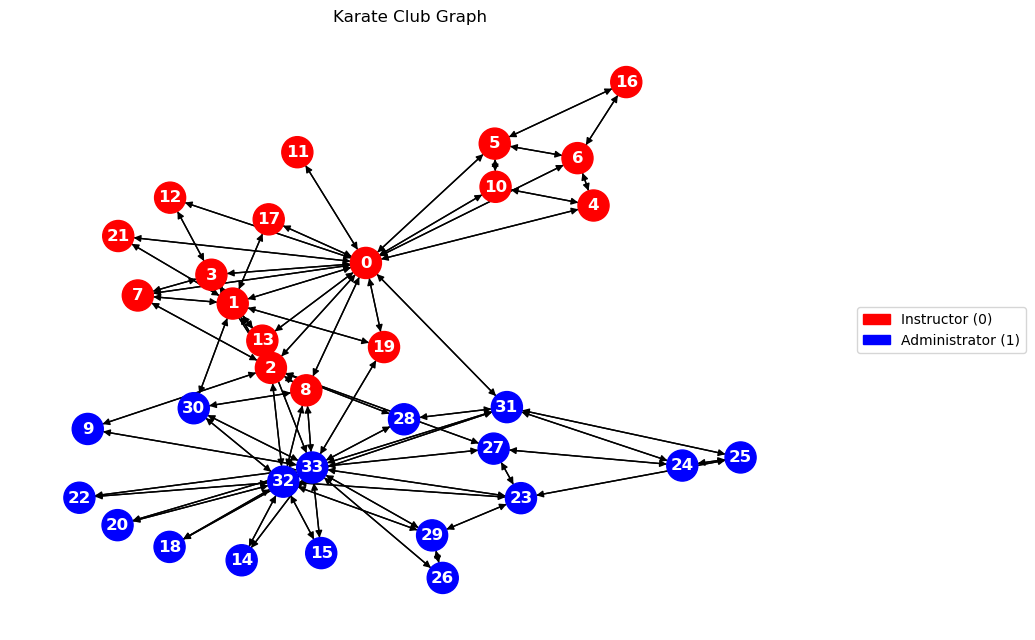

In [49]:

plt.figure(figsize=(8, 6))
nx.draw(
    nx_g,
    pos,
    node_color=color_map,
    with_labels=True,
    node_size=500,
    font_color='white',
    font_weight='bold'
)


# Add legend, pushed to the right
red_patch = mpatches.Patch(color='red', label='Instructor (0)')
blue_patch = mpatches.Patch(color='blue', label='Administrator (1)')
plt.legend(
    handles=[red_patch, blue_patch],
    loc='center left',
    bbox_to_anchor=(1.05, 0.5),
    borderaxespad=0.5
)

plt.title("Karate Club Graph")
plt.show()

### 4. Vertex Embedding Initialization

In [36]:
#embed vertices with a dimension of 6
vert_em = nn.Embedding(g.number_of_nodes(),6) 
inputs = vert_em.weight                  
nn.init.xavier_uniform_(inputs)

Parameter containing:
tensor([[-0.3839,  0.3366,  0.3250, -0.3235, -0.1029,  0.1601],
        [-0.0444, -0.0051, -0.1778,  0.3232,  0.0138, -0.3155],
        [-0.1771,  0.0206, -0.2115,  0.3751, -0.3762, -0.1868],
        [ 0.2979,  0.0071,  0.1580,  0.2382, -0.0184,  0.3681],
        [-0.1218,  0.3441, -0.1918, -0.1100, -0.2124, -0.1655],
        [ 0.0439, -0.1344, -0.3756, -0.2726,  0.3703, -0.1968],
        [ 0.0898,  0.2588, -0.1842,  0.1227, -0.2555,  0.0817],
        [ 0.2905,  0.3240,  0.2845,  0.2943,  0.3352, -0.2059],
        [-0.0108,  0.3753,  0.0184,  0.1969,  0.3564,  0.2538],
        [ 0.1314,  0.3552,  0.1383,  0.1649, -0.3655, -0.0353],
        [-0.1076,  0.1840,  0.0737, -0.0484,  0.1049, -0.3330],
        [-0.1191, -0.2971,  0.3748, -0.2425, -0.0972,  0.3501],
        [ 0.2689,  0.2638,  0.1053, -0.2330,  0.2786, -0.2120],
        [-0.0261,  0.0929,  0.2541, -0.1703,  0.0860, -0.3395],
        [ 0.1636, -0.2502,  0.1494,  0.0418,  0.1736,  0.0476],
        [ 0.0062, 

---

**What does this step do and Why?**

In many real-world GNN tasks, nodes come with features like age, role, or account activity. But in this synthetic example, we don't have any. To make learning possible:

* We simulate node features via **randomly initialized embeddings using Xavier uniform initialization**.
* These embeddings will be **updated and learned** during training to capture meaningful representations of each node's role in the graph.

---

Let’s break this down step by step:

1. **`nn.Embedding(g.number_of_nodes(), 6)`**

   * This creates a **learnable embedding matrix** with `g.number_of_nodes()` rows and `6` columns.
   * Each row is a 6-dimensional vector representing one node (club member).
   * Since there are 34 nodes, this gives us a 34 × 6 matrix.
   * This is needed because the original graph **does not include node features**—just edges and labels. So we create synthetic features (i.e., embeddings) for learning.
<div style="margin-bottom: 6px;"></div>

2. **`inputs = vert_em.weight`**

   * This retrieves the **actual embedding tensor** (of shape `[34, 6]`) from the `nn.Embedding` layer.
   * This will be used as input features to the GNN.
<div style="margin-bottom: 6px;"></div>

3. **`nn.init.xavier_uniform_(inputs)`**

   * This initializes the weights (embedding vectors) using **Xavier uniform initialization**, which is a common choice in deep learning.
   * Xavier initialization helps ensure the variance of activations remains stable across layers, which improves training efficiency.
<div style="margin-bottom: 6px;"></div>

---



### 5. **GraphSAGE** 

It is a framework that enables inductive learning on graphs. Unlike GCNs, which require the entire graph during training, GraphSAGE learns a function to generate node embeddings by sampling and aggregating information from a node's local neighborhood. This makes it scalable and applicable to unseen nodes (e.g. new users or accounts in financial crime). 

In [50]:
#obtain labels and denote available labels for GNN learning (here: 1, 3, 5, 12, 15, 32)
labels = g.ndata['label']
labeled_nodes = [1, 3, 5, 12, 15, 32]

In [22]:
#build a three-layer GraphSAGE model
class GraphSAGE(nn.Module):
    def __init__(self, in_feats, h_feats1, h_feats2, num_classes):
        super(GraphSAGE, self).__init__()
        self.conv1 = SAGEConv(in_feats, h_feats1, 'mean')
        self.conv2 = SAGEConv(h_feats1, h_feats2, 'mean')
        self.conv3 = SAGEConv(h_feats2, num_classes, 'mean')
    def forward(self, g, in_feat):
        h = self.conv1(g, in_feat)
        h = F.relu(h)
        h = self.conv2(g, h)
        h = F.relu(h)
        h = self.conv3(g, h)
        return h

#6 embedding dimensions as input, a hidden layers of 8 and 6 nodes, and 2 classes to output
net = GraphSAGE(6,8,6,2)

#GNN training parameters
optimizer=torch.optim.SGD(itertools.chain(net.parameters(), vert_em.parameters()),lr=0.01,
                          momentum=0.8)
all_logits = []

#train GNN
for e in range(2000):
    logits = net(g, inputs)
    logp = F.log_softmax(logits, 1)
    loss = F.nll_loss(logp[labeled_nodes], labels[labeled_nodes])
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    all_logits.append(logits.detach())
    if e % 90 == 0:
        print('In epoch {}, loss: {}'.format(e, loss))

In epoch 0, loss: 0.7228014469146729
In epoch 90, loss: 0.022204509004950523
In epoch 180, loss: 0.00729841785505414
In epoch 270, loss: 0.003980547655373812
In epoch 360, loss: 0.0026449754368513823
In epoch 450, loss: 0.001946722506545484
In epoch 540, loss: 0.0015204738592728972
In epoch 630, loss: 0.001236315700225532
In epoch 720, loss: 0.0010349954245612025
In epoch 810, loss: 0.0008857588400132954
In epoch 900, loss: 0.0007705257157795131
In epoch 990, loss: 0.0006778924143873155
In epoch 1080, loss: 0.0006032592500559986
In epoch 1170, loss: 0.000542281661182642
In epoch 1260, loss: 0.0004916658508591354
In epoch 1350, loss: 0.00044881206122227013
In epoch 1440, loss: 0.000412073073675856
In epoch 1530, loss: 0.00038047635462135077
In epoch 1620, loss: 0.0003529897367116064
In epoch 1710, loss: 0.00032891836599446833
In epoch 1800, loss: 0.00030764692928642035
In epoch 1890, loss: 0.0002887583978008479
In epoch 1980, loss: 0.00027187561499886215


In [23]:
#obtain accuracy statistics
pred = torch.argmax(logits, axis=1)
print('Accuracy', (pred == labels).sum().item() / len(pred))

Accuracy 0.8823529411764706
